# **Modelo Supervisado de Clasificación**
## ATUS Anual 2024
### Proyecto Final — Almacenes y Minería de Datos

Este notebook implementa el modelo supervisado de clasificación para predecir la severidad
de los accidentes de tránsito registrados en México durante 2024, utilizando el dataset
limpio generado en el notebook de análisis exploratorio y tomando en cuenta las observaciones 
hechas en en notebook de análisis descriptivo estadístico.

La variable objetivo es `CLASACC`, que distingue tres niveles de severidad:
- **Sólo daños:** el accidente únicamente generó daños materiales (~82% de los registros)
- **No fatal:** el accidente dejó personas heridas pero sin fallecimientos (~17%)
- **Fatal:** el accidente resultó en al menos una persona fallecida (~1.1%)

El desbalance severo entre clases es el principal desafío técnico de esta tarea y guiará
las decisiones de preprocesamiento, selección de modelo y evaluación.

# **Estrategia General**

Antes de comenzar con la carga de datos y el preprocesamiento, se define la estrategia
general de modelado que guiará todas las decisiones técnicas de este notebook.

---

## **Tarea y variable objetivo**

La tarea es una **clasificación multiclase** sobre la variable `CLASACC`, que distingue
tres niveles de severidad de los accidentes de tránsito:

- `Sólo daños` — únicamente daños materiales (~82% de los registros)
- `No fatal` — personas heridas sin fallecimientos (~17%)
- `Fatal` — al menos una persona fallecida (~1.1%)

El **desbalance severo** entre clases es el principal desafío técnico. Un modelo que ignore
completamente la clase `Fatal` puede alcanzar 98% de accuracy y ser completamente inútil
para el objetivo del proyecto. Por esta razón, la métrica principal de comparación será el
**F1-score macro**, que pondera por igual las tres clases sin importar su frecuencia.

---

## **Modelos**

Se implementan cuatro modelos en orden creciente de complejidad:

**Línea base trivial** — Clasificador mayoritario que siempre predice `Sólo daños`.
Alcanzará ~82% de accuracy con 0% de recall en `Fatal` y `No fatal`. Es el piso mínimo
obligatorio que cualquier modelo real debe superar.

**Logistic Regression** — Modelo lineal interpretable y rápido. Funciona como segunda
línea de referencia antes de modelos más complejos. Maneja el desbalance de clases
mediante `class_weight='balanced'`.

**Random Forest** — Modelo principal del proyecto. Maneja variables mixtas, es robusto
frente al desbalance con `class_weight='balanced'`, escala bien con 374,078 registros y
produce importancia de características de forma nativa, insumo directo para la etapa
de agrupamiento no supervisado del proyecto.

**XGBoost** — Modelo de reserva. Se entrenará únicamente si Random Forest no produce
resultados satisfactorios. Generalmente supera a Random Forest en datasets tabulares con
desbalance severo, pero requiere mayor costo computacional y ajuste de hiperparámetros.

---

## **Plan de contingencia**

Si los resultados de la clasificación multiclase son insatisfactorios, particularmente
si el recall de `Fatal` es inaceptablemente bajo en todos los modelos, se reformulará
el problema como **clasificación binaria**: `Fatal` vs `No fatal + Sólo daños`, poniendo
el foco en identificar correctamente los accidentes más graves.

---

### **Configuración Global**

Las siguientes constantes controlan el comportamiento reproducible del notebook.
`RANDOM_STATE` se usa como semilla en todos los procesos estocásticos: división
de datos, entrenamiento de modelos y ajuste de hiperparámetros.

In [4]:
RANDOM_STATE = 42

## **1. Carga y Verificación del Dataset**

En esta sección se carga el dataset limpio generado en el notebook de análisis exploratorio
(`atus_anual_2024_limpio.csv`) utilizando la clase `DataRepository`, que abstrae el acceso
al archivo y valida automáticamente que el dataset contenga las columnas mínimas requeridas
antes de continuar con el pipeline de modelado.

In [5]:
import sys
sys.path.append('../src/supervised/')


from data_repository import DataRepository

repo = DataRepository("../data/atus_anual_2024_limpio.csv")
df = repo.load()

print(repo.summary())

           RESUMEN DEL DATASET CARGADO
  Ruta:          ..\data\atus_anual_2024_limpio.csv
  Configuración: C:\Users\grame\Desktop\Tareas_Almacenes-y-Mineria-de-Datos\ProyectoFinal\notebooks\..\src\supervised\config\repository_config.yaml
  Filas:         374,078
  Columnas:      42

  Distribución de CLASACC (variable objetivo):
    Sólo daños   306,088  (81.82%)
    No fatal      63,809  (17.06%)
    Fatal          4,181  (1.12%)

  Valores nulos por columna:
    ID_EDAD                    96,222


El resumen confirma que el dataset fue cargado correctamente y que la distribución de
`CLASACC` presenta el desbalance severo esperado: aproximadamente 82% de los registros
corresponden a `Sólo daños`, 17% a `No fatal` y apenas 1.1% a `Fatal`. Este desbalance
es el principal desafío técnico del modelo y guiará las decisiones de preprocesamiento
y evaluación en las secciones siguientes.

## **2. Selección y Justificación de Variables de Entrada**

Antes de construir el pipeline de preprocesamiento, se analizan todas las variables disponibles
en el dataset limpio para determinar cuáles se incluyen como features del modelo y cuáles se
excluyen. Las decisiones se toman con base en el EDA, el dominio del problema y criterios
técnicos de modelado.

---

### Variables excluidas

| Variable | Razón |
|---|---|
| `ID_MINUTO` | Granularidad excesiva sin relación causal con la severidad del accidente |
| `ID_DIA` | El día del mes no tiene relación causal con la severidad |
| `NOM_MUN` | 1,435 categorías únicas — cardinalidad demasiado alta para encoding |
| `TRANVIA` | Prácticamente sin variación real (2 valores únicos) |
| `FERROCARRI` | Prácticamente sin variación real (2 valores únicos) |
| `OTROVEHIC` | Prácticamente sin variación real (2 valores únicos) |
| `TOTAL_MUERTOS` | **Data leakage** — variable derivada directamente de la objetivo |
| `CONDMUERTO`, `CONDHERIDO` | **Data leakage** — el número de víctimas es consecuencia, no causa |
| `PASAMUERTO`, `PASAHERIDO` | **Data leakage** — ídem |
| `PEATMUERTO`, `PEATHERIDO` | **Data leakage** — ídem |
| `CICLMUERTO`, `CICLHERIDO` | **Data leakage** — ídem |
| `OTROMUERTO`, `OTROHERIDO` | **Data leakage** — ídem |

Las columnas de víctimas merecen una explicación especial. Si bien tienen una correlación
directa con `CLASACC`, un accidente con `CONDMUERTO > 0` es casi inevitablemente `Fatal`,
**incluirlas produciría un modelo trivialmente perfecto pero inútil en producción**. En un
escenario real, la severidad del accidente se desconoce en el momento en que se quiere
predecir; las víctimas son una consecuencia del accidente, no una característica observable
previa a su clasificación.

---

### Variables numéricas

| Variable | Transformación |
|---|---|
| `ID_EDAD` | Imputación con mediana (solo entrenamiento) + StandardScaler |
| `AUTOMOVIL`, `CAMPASAJ`, `MICROBUS`, `PASCAMION` | StandardScaler |
| `OMNIBUS`, `CAMIONETA`, `CAMION`, `TRACTOR` | StandardScaler |
| `MOTOCICLET`, `BICICLETA` | StandardScaler |
| `CONDUCTOR_FUGADO`, `EDAD_DESCONOCIDA` | Binarias — sin escalado |

---

### Variables temporales — Encoding cíclico

`MES` e `ID_HORA` tienen naturaleza circular: la hora 23 está temporalmente cerca de la
hora 0, y diciembre está cerca de enero. Un escalado lineal no captura esta continuidad.
Por esta razón se aplica **encoding cíclico** mediante transformaciones seno/coseno:

$$\text{MES\_SEN} = \sin\left(\frac{2\pi \cdot \text{MES}}{12}\right) \quad
\text{MES\_COS} = \cos\left(\frac{2\pi \cdot \text{MES}}{12}\right)$$

$$\text{HORA\_SEN} = \sin\left(\frac{2\pi \cdot \text{ID\_HORA}}{24}\right) \quad
\text{HORA\_COS} = \cos\left(\frac{2\pi \cdot \text{ID\_HORA}}{24}\right)$$

Las columnas originales `MES` e `ID_HORA` se eliminan tras la transformación.

---

### Variables categóricas — One-Hot Encoding

| Variable | Valores únicos |
|---|---|
| `DIASEMANA` | 7 |
| `URBANA` | 3 |
| `SUBURBANA` | 4 |
| `TIPACCID` | 12 |
| `CAUSAACCI` | 5 |
| `CAPAROD` | 2 |
| `SEXO` | 3 |
| `ALIENTO` | 3 |
| `CINTURON` | 3 |
| `NOM_ENT` | 32 |

Se aplica `OneHotEncoder` con `drop='first'` para evitar multicolinealidad perfecta entre
las categorías de cada variable.

---

### Resumen

En total se incluyen **26 variables originales** que tras las transformaciones producen un
espacio de features con codificación numérica completa, libre de data leakage y lista para
ser consumida por los modelos de clasificación.

In [6]:
from preprocessor import Preprocessor
from sklearn.model_selection import train_test_split

# Separación de features y variable objetivo
y = df[repo.target_column]
X = df.drop(columns=[repo.target_column])

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nDistribución de y:")
print(y.value_counts())

Shape de X: (374078, 41)
Shape de y: (374078,)

Distribución de y:
CLASACC
Sólo daños    306088
No fatal       63809
Fatal           4181
Name: count, dtype: int64


In [7]:
# División en entrenamiento y prueba antes de ajustar el preprocesador
# IMPORTANTE: el preprocesador se ajusta SOLO sobre X_train para
# evitar data leakage en la imputación de ID_EDAD
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y      # Preserva la distribución de clases en ambos conjuntos
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print(f"\nDistribución en prueba:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train: (299262, 41)  |  X_test: (74816, 41)

Distribución en entrenamiento:
CLASACC
Sólo daños    81.82
No fatal      17.06
Fatal          1.12
Name: proportion, dtype: float64

Distribución en prueba:
CLASACC
Sólo daños    81.82
No fatal      17.06
Fatal          1.12
Name: proportion, dtype: float64


In [8]:
# Ajuste y transformación de X
prep = Preprocessor()
print(prep.summary())

X_train_t = prep.fit_transform(X_train)
X_test_t  = prep.transform(X_test)

print(f"\nShape X_train transformado: {X_train_t.shape}")
print(f"Shape X_test transformado:  {X_test_t.shape}")
print(f"Total features:             {len(prep.feature_names)}")

        CONFIGURACIÓN DEL PREPROCESADOR
  Configuración: C:\Users\grame\Desktop\Tareas_Almacenes-y-Mineria-de-Datos\ProyectoFinal\notebooks\..\src\supervised\config\preprocessor_config.yaml

  Columnas excluidas      (17):
    - ID_MINUTO
    - ID_DIA
    - NOM_MUN
    - TRANVIA
    - FERROCARRI
    - OTROVEHIC
    - TOTAL_MUERTOS
    - CONDMUERTO
    - CONDHERIDO
    - PASAMUERTO
    - PASAHERIDO
    - PEATMUERTO
    - PEATHERIDO
    - CICLMUERTO
    - CICLHERIDO
    - OTROMUERTO
    - OTROHERIDO

  Numéricas               (11): Imputer(mediana) + StandardScaler
    - ID_EDAD
    - AUTOMOVIL
    - CAMPASAJ
    - MICROBUS
    - PASCAMION
    - OMNIBUS
    - CAMIONETA
    - CAMION
    - TRACTOR
    - MOTOCICLET
    - BICICLETA

  Binarias                (2): passthrough
    - CONDUCTOR_FUGADO
    - EDAD_DESCONOCIDA

  Categóricas             (10): OneHotEncoder(drop='first')
    - DIASEMANA
    - URBANA
    - SUBURBANA
    - TIPACCID
    - CAUSAACCI
    - CAPAROD
    - SEXO
    - ALIENT

In [9]:
# Ajuste y transformación de Y ( usado en XGBoost )
y_train_enc = prep.fit_transform_target(y_train)
y_test_enc  = prep.transform_target(y_test)

Clases codificadas:
  0 → Fatal
  1 → No fatal
  2 → Sólo daños


### Resultado del preprocesamiento

El pipeline transforma las 26 variables originales seleccionadas en **81 features numéricas**
listas para el modelado. El incremento se debe principalmente al One-Hot Encoding de las
variables categóricas, que expande cada categoría en una columna binaria independiente.

**Sobre la división antes del preprocesamiento:**
La separación en `X_train` y `X_test` se realizó **antes** de ajustar el preprocesador,
y este se ajustó **exclusivamente sobre `X_train`**. Esto es fundamental para evitar
*data leakage* en la etapa de imputación de `ID_EDAD`.

`SimpleImputer` calcula la mediana de `ID_EDAD` durante `fit()` y la usa para rellenar
los valores `NaN` en cualquier conjunto posterior. Si se ajustara sobre el dataset completo,
la mediana incorporaría información de los datos de prueba, dándole al modelo una ventaja
irreal que no existiría en producción. Al ajustar solo sobre `X_train`, la mediana refleja
únicamente lo que el modelo "conoce" durante el entrenamiento, y esa misma mediana se aplica
a `X_test` y a cualquier dato nuevo, replicando fielmente el comportamiento en producción.

El parámetro `stratify=y` en `train_test_split` garantiza que la distribución de `CLASACC`
se preserve en ambos conjuntos, lo cual es especialmente importante dado el desbalance
severo de la clase `Fatal` (~1.1%).

## **4. Inicialización de Modelos**

Se instancian los modelos usando `ModelFactory`, que centraliza la creación y configuración
de cada algoritmo. Los hiperparámetros base se cargan desde el archivo YAML de configuración
y `RANDOM_STATE` sobreescribe la semilla en todos los modelos para garantizar
reproducibilidad.

In [10]:
from model_factory import ModelFactory

print(ModelFactory.summary())

         MODELOS DISPONIBLES — ModelFactory
  Configuración: C:\Users\grame\Desktop\Tareas_Almacenes-y-Mineria-de-Datos\ProyectoFinal\notebooks\..\src\supervised\config\model_factory_config.yaml

  [dummy]
    strategy                  most_frequent

  [logistic_regression]
    max_iter                  1000
    class_weight              balanced
    random_state              42
    solver                    lbfgs

  [random_forest]
    n_estimators              100
    max_depth                 None
    min_samples_split         2
    min_samples_leaf          1
    class_weight              balanced
    random_state              42
    n_jobs                    2

  [xgboost]
    n_estimators              100
    max_depth                 6
    learning_rate             0.1
    subsample                 0.8
    colsample_bytree          0.8
    use_label_encoder         False
    eval_metric               mlogloss
    random_state              42
    n_jobs                    2



In [11]:
dummy_model = ModelFactory.create('dummy')
lr_model    = ModelFactory.create('logistic_regression', random_state=RANDOM_STATE)
rf_model    = ModelFactory.create('random_forest',       random_state=RANDOM_STATE)
xgb_model   = ModelFactory.create('xgboost',             random_state=RANDOM_STATE)


print("Modelos inicializados:")
print(f"  Línea base:          {dummy_model}")
print(f"  Logistic Regression: {lr_model}")
print(f"  Random Forest:       {rf_model}")
print(f"  Xgboost:             {xgb_model}")

Modelos inicializados:
  Línea base:          DummyClassifier(strategy='most_frequent')
  Logistic Regression: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
  Random Forest:       RandomForestClassifier(class_weight='balanced', n_jobs=2, random_state=42)
  Xgboost:             XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strate

Los tres modelos están configurados con `class_weight='balanced'` donde aplica, lo que
le indica a scikit-learn que compense automáticamente el desbalance de clases ajustando
el peso de cada clase inversamente proporcional a su frecuencia. Esto es especialmente
importante para la clase `Fatal`, que representa apenas el 1.1% de los registros.

## 5. **Entrenamiento de Modelos**

Se entrena cada modelo usando `Trainer`, que encapsula la validación cruzada, el ajuste
de hiperparámetros con `GridSearchCV` y la medición del tiempo de entrenamiento. Los
modelos se entrenan uno a la vez para mantener la trazabilidad de cada experimento.

La métrica principal de optimización es **F1-score macro**, que pondera por igual las
tres clases de `CLASACC` independientemente de su frecuencia.

In [12]:
from trainer import Trainer

trainer = Trainer(random_state=RANDOM_STATE)

### 5.1 Línea Base Trivial — Clasificador Mayoritario

In [14]:
best_dummy, results_dummy = trainer.fit(dummy_model, X_train_t, y_train_enc, 'dummy')
print(trainer.summary())
trainer.save_model(best_dummy, 'dummy',  output_dir='../models')

[dummy] Ejecutando validación cruzada (3 folds)...
[dummy] CV f1_macro: 0.3000 ± 0.0000 (6.17s)
[dummy] Entrenando modelo (sin GridSearchCV)...
[dummy] Entrenamiento completado (0.01s)
   RESULTADOS DE ENTRENAMIENTO — dummy
  Validación cruzada (3 folds, f1_macro):
    Scores por fold:  [0.3 0.3 0.3]
    Media:            0.3000
    Desv. estándar:   0.0000
    Tiempo CV:        6.17s

  Ajuste de hiperparámetros (GridSearchCV):
    Sin GridSearchCV (param_grid vacío)

  Tiempo GridSearchCV:  0.01s
  Tiempo total:         6.18s
[dummy] Modelo guardado en: ..\models\dummy.joblib


WindowsPath('../models/dummy.joblib')

### 5.2 Logistic Regression

In [15]:
from sklearn.model_selection import train_test_split

# Muestra estratificada del 30% para Logistic Regression
X_train_lr, _, y_train_lr, _ = train_test_split(
    X_train_t, y_train,
    train_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Shape X_train_lr: {X_train_lr.shape}")
print(f"Distribución y_train_lr:")
print(y_train_lr.value_counts(normalize=True).mul(100).round(2))

Shape X_train_lr: (89778, 81)
Distribución y_train_lr:
CLASACC
Sólo daños    81.83
No fatal      17.06
Fatal          1.12
Name: proportion, dtype: float64


In [11]:
best_lr, results_lr = trainer.fit(lr_model, X_train_lr, y_train_lr, 'logistic_regression')
print(trainer.summary())
trainer.save_model(best_lr, 'logistic_regression', output_dir='../models')

[logistic_regression] Ejecutando validación cruzada (3 folds)...
[logistic_regression] CV f1_macro: 0.4825 ± 0.0027 (11.99s)
[logistic_regression] Ejecutando GridSearchCV...
[logistic_regression] Mejores parámetros: {'C': 10.0, 'solver': 'saga'}
[logistic_regression] Mejor f1_macro: 0.4833 (433.19s)
   RESULTADOS DE ENTRENAMIENTO — logistic_regression
  Validación cruzada (3 folds, f1_macro):
    Scores por fold:  [0.4815 0.4863 0.4799]
    Media:            0.4825
    Desv. estándar:   0.0027
    Tiempo CV:        11.99s

  Ajuste de hiperparámetros (GridSearchCV):
    C                         10.0
    solver                    saga
    Mejor f1_macro:      0.4833

  Tiempo GridSearchCV:  433.19s
  Tiempo total:         445.18s
[logistic_regression] Modelo guardado en: models\logistic_regression.joblib


C:\Users\grame\Desktop\Tareas_Almacenes-y-Mineria-de-Datos\ProyectoFinal\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


WindowsPath('models/logistic_regression.joblib')

### 5.3 Random Forest

In [49]:
best_rf, results_rf = trainer.fit(rf_model, X_train_t, y_train_enc, 'random_forest')
print(trainer.summary())
trainer.save_model(best_rf, 'random_forest', output_dir='../models')

[random_forest] Ejecutando validación cruzada (3 folds)...
[random_forest] CV f1_macro: 0.5239 ± 0.0040 (40.58s)
[random_forest] Ejecutando GridSearchCV...
[random_forest] Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
[random_forest] Mejor f1_macro: 0.5482 (385.14s)
   RESULTADOS DE ENTRENAMIENTO — random_forest
  Validación cruzada (3 folds, f1_macro):
    Scores por fold:  [0.5296 0.521  0.5212]
    Media:            0.5239
    Desv. estándar:   0.0040
    Tiempo CV:        40.58s

  Ajuste de hiperparámetros (GridSearchCV):
    max_depth                 None
    min_samples_leaf          2
    n_estimators              100
    Mejor f1_macro:      0.5482

  Tiempo GridSearchCV:  385.14s
  Tiempo total:         425.72s
[random_forest] Modelo guardado en: ..\models\random_forest.joblib


WindowsPath('../models/random_forest.joblib')

### 5.4 XGBoost

In [41]:
best_xgb, results_xgb = trainer.fit(xgb_model, X_train_t, y_train_enc, 'xgboost')
print(trainer.summary())
trainer.save_model(best_xgb, 'xgboost', output_dir='../models')

[xgboost] Ejecutando validación cruzada (3 folds)...
[xgboost] CV f1_macro: 0.5005 ± 0.0016 (37.36s)
[xgboost] Ejecutando GridSearchCV...


C:\Users\grame\Desktop\Tareas_Almacenes-y-Mineria-de-Datos\ProyectoFinal\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:44:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[xgboost] Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
[xgboost] Mejor f1_macro: 0.5253 (1511.68s)
   RESULTADOS DE ENTRENAMIENTO — xgboost
  Validación cruzada (3 folds, f1_macro):
    Scores por fold:  [0.4984 0.501  0.5022]
    Media:            0.5005
    Desv. estándar:   0.0016
    Tiempo CV:        37.36s

  Ajuste de hiperparámetros (GridSearchCV):
    colsample_bytree          0.8
    learning_rate             0.2
    max_depth                 6
    n_estimators              300
    subsample                 0.8
    Mejor f1_macro:      0.5253

  Tiempo GridSearchCV:  1511.68s
  Tiempo total:         1549.04s
[xgboost] Modelo guardado en: models\xgboost.joblib


WindowsPath('models/xgboost.joblib')

## **6. Evaluación de Modelos**

En esta sección se evalúan los modelos entrenados sobre el conjunto de prueba `X_test_t`,
que no fue utilizado en ninguna etapa del entrenamiento ni del ajuste de hiperparámetros.
Se calculan métricas completas y se generan visualizaciones para cada modelo.

La métrica principal de comparación es el **F1-score macro**, complementada con el reporte
completo por clase para analizar el comportamiento del modelo en cada nivel de severidad,
especialmente en la clase `Fatal` (~1.1% de los datos).

In [43]:
from evaluator import Evaluator

evaluator = Evaluator(prep.target_classes)

### 6.1 Línea Base Trivial — Clasificador Mayoritario

In [46]:
evaluator.evaluate(best_dummy, X_test_t, y_test_enc, 'dummy')
print(evaluator.summary())

   MÉTRICAS DE EVALUACIÓN — dummy
  Accuracy:             0.8182

  Métrica                 Macro  Ponderado
  ----------------------------------------
  Precision              0.2727     0.6695
  Recall                 0.3333     0.8182
  F1-score               0.3000     0.7365

  Reporte completo por clase:
              precision    recall  f1-score   support

       Fatal       0.00      0.00      0.00       836
    No fatal       0.00      0.00      0.00     12762
  Sólo daños       0.82      1.00      0.90     61218

    accuracy                           0.82     74816
   macro avg       0.27      0.33      0.30     74816
weighted avg       0.67      0.82      0.74     74816



La línea base predice siempre `Sólo daños`, la clase mayoritaria. Como era de esperarse,
obtiene un accuracy aparentemente alto (~82%) pero Precision, Recall y F1-score de 0 para
`Fatal` y `No fatal`. Este resultado confirma que el **accuracy no es una métrica confiable**
para este problema y justifica el uso de F1-score macro como métrica principal.

Cualquier modelo real debe superar estos resultados para aportar valor predictivo.

### 6.2 Logistic Regression

El entrenamiento de Logistic Regression presentó problemas de convergencia con el dataset
completo y con una muestra del 30% (~90k registros). El algoritmo `saga` no logró converger
en el número máximo de iteraciones configurado (`max_iter=1000`), lo que indica que el
espacio de features de 81 dimensiones y el desbalance severo de clases representan un
desafío significativo para un **modelo lineal**.

Por esta razón, Logistic Regression se descarta como candidato.

Esta limitación es en sí misma un hallazgo relevante: sugiere que **la relación entre las
variables predictoras y la severidad del accidente no es linealmente separable**, justificando
el uso de modelos más complejos como XGBoost.

In [47]:
evaluator.evaluate(best_lr, X_train_lr, y_train_lr, 'logistic_regression')
print(evaluator.summary())

   MÉTRICAS DE EVALUACIÓN — logistic_regression
  Accuracy:             0.7304

  Métrica                 Macro  Ponderado
  ----------------------------------------
  Precision              0.4882     0.8493
  Recall                 0.6566     0.7304
  F1-score               0.4836     0.7799

  Reporte completo por clase:
              precision    recall  f1-score   support

       Fatal       0.06      0.66      0.10      1003
    No fatal       0.47      0.54      0.50     15314
  Sólo daños       0.94      0.77      0.85     73461

    accuracy                           0.73     89778
   macro avg       0.49      0.66      0.48     89778
weighted avg       0.85      0.73      0.78     89778



### 6.3 Random Forest

In [60]:
evaluator.evaluate(best_rf, X_test_t, y_test_enc, 'random_forest')
print(evaluator.summary())

   MÉTRICAS DE EVALUACIÓN — random_forest
  Accuracy:             0.8193

  Métrica                 Macro  Ponderado
  ----------------------------------------
  Precision              0.5259     0.8526
  Recall                 0.5794     0.8193
  F1-score               0.5453     0.8312

  Reporte completo por clase:
              precision    recall  f1-score   support

       Fatal       0.14      0.18      0.16       836
    No fatal       0.50      0.71      0.59     12762
  Sólo daños       0.94      0.85      0.89     61218

    accuracy                           0.82     74816
   macro avg       0.53      0.58      0.55     74816
weighted avg       0.85      0.82      0.83     74816



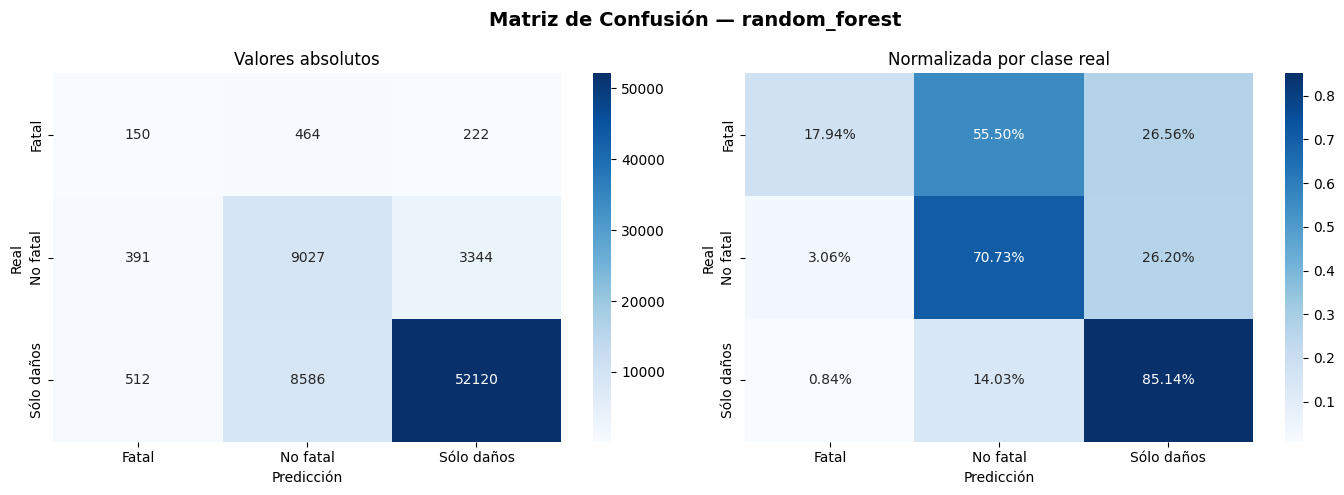

Guardada en: reports\model_evaluation\random_forest\confusion_matrix.png


WindowsPath('reports/model_evaluation/random_forest/confusion_matrix.png')

In [51]:
evaluator.plot_confusion_matrix('random_forest')

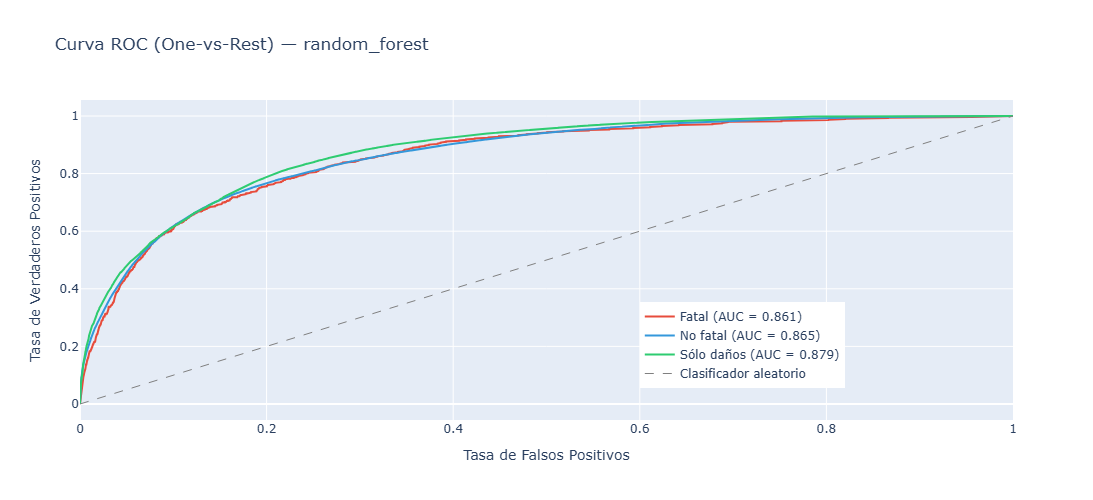

Guardada en: reports\model_evaluation\random_forest\roc_curve.html


WindowsPath('reports/model_evaluation/random_forest/roc_curve.html')

In [52]:
evaluator.plot_roc_curve('random_forest', X_test_t, y_test_enc)

C:\Users\grame\Desktop\Tareas_Almacenes-y-Mineria-de-Datos\ProyectoFinal\notebooks\../src\evaluator.py:327: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


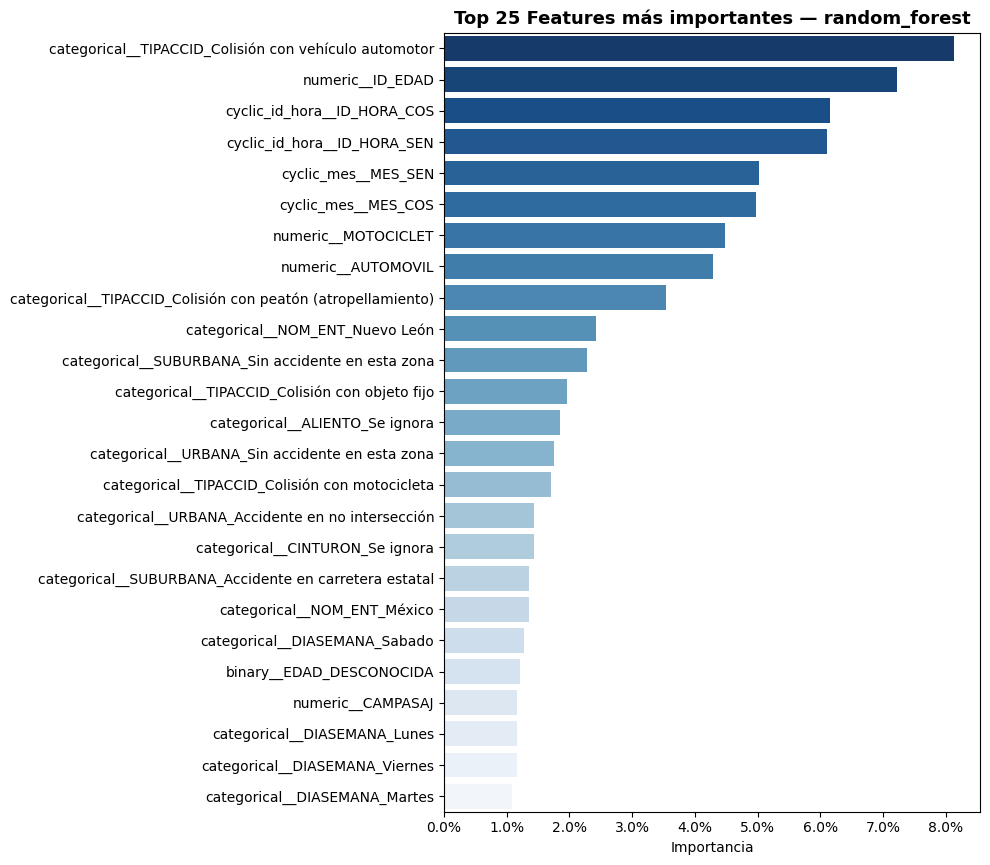

Guardada en: reports\model_evaluation\random_forest\feature_importance.png
CSV guardado en: reports\model_evaluation\random_forest\feature_importance.csv


WindowsPath('reports/model_evaluation/random_forest/feature_importance.png')

In [53]:
evaluator.plot_feature_importance(best_rf, prep.feature_names, 'random_forest')

#### Análisis de resultados — Random Forest

**Accuracy: 0.8193** — engañosamente alto debido al desbalance de clases. Un clasificador
que predijera siempre `Sólo daños` obtendría ~82% de accuracy sin ningún valor predictivo
real, por lo que esta métrica no es representativa del desempeño real del modelo.

**F1-score macro: 0.5453** — supera ampliamente la línea base trivial y es la métrica
más honesta para este problema, ya que pondera por igual las tres clases.

**Análisis por clase:**

- **`Sólo daños` (F1=0.89):** El modelo identifica correctamente el 85% de los accidentes
  con solo daños materiales. Su alta precision (0.94) indica que cuando predice esta clase,
  casi siempre tiene razón.

- **`No fatal` (F1=0.59):** Desempeño aceptable con recall de 0.71. El modelo identifica
  7 de cada 10 accidentes con personas heridas, aunque el 26% se clasifica erróneamente
  como `Sólo daños`.

- **`Fatal` (F1=0.16):** La clase más problemática. Con recall de apenas 0.18, el modelo
  falla en identificar 8 de cada 10 accidentes fatales. La baja precision (0.14) indica
  además que la mayoría de sus predicciones de `Fatal` son incorrectas. Este resultado
  era esperado dado que solo el 1.1% de los registros pertenecen a esta clase.

**Limitación principal:** El bajo desempeño en `Fatal` es la limitación más significativa
del modelo. En un contexto real, fallar en identificar un accidente fatal tiene consecuencias
mucho más graves que clasificar incorrectamente un accidente de solo daños. Esta asimetría
en el costo de los errores sugiere que se debería explorar estrategias adicionales como
oversampling (SMOTE) o ajuste manual de umbrales de clasificación como trabajo futuro.

**Curva ROC**

La curva ROC evalúa la capacidad discriminativa del modelo para cada clase de forma
independiente del umbral de clasificación, bajo el enfoque *One-vs-Rest*: en cada
curva, el modelo intenta distinguir una clase del resto.

Los tres AUC obtenidos son consistentemente altos:

| Clase | AUC |
|---|---|
| `Fatal` | 0.861 |
| `No fatal` | 0.865 |
| `Sólo daños` | 0.879 |

El hallazgo más relevante es la aparente contradicción entre el AUC de `Fatal` (0.861)
y su recall de apenas 0.18. Un AUC cercano a 0.86 indica que el modelo **sí tiene
capacidad discriminativa** para identificar accidentes fatales, puede ordenar
correctamente los casos por probabilidad de fatalidad. El problema no es que el modelo
no pueda distinguirlos, sino que el **umbral de clasificación por defecto (0.5) está mal
calibrado** para una clase tan minoritaria (1.1%). Con un umbral más bajo para `Fatal`,
el recall podría mejorar a costa de un mayor número de falsos positivos.
Explorar el ajuste de umbrales representa una línea de trabajo con alto potencial
de mejora que veremos en la siguiente sección.

---

**Importancia de características**

La gráfica muestra la contribución relativa de cada feature a las decisiones del modelo,
calculada como el promedio de reducción de impureza en todos los árboles del ensamble.

Los hallazgos más relevantes son:

- **`TIPACCID_Colisión con vehículo automotor` (8%):** El tipo de accidente más frecuente
  es el predictor más importante. Las colisiones entre vehículos tienen patrones de
  severidad muy distintos a otros tipos de percance.

- **`ID_EDAD` (7.3%):** La edad del conductor es el segundo predictor más importante,
  confirmando la relación entre edad y severidad identificada en el análisis descriptivo.

- **`ID_HORA_COS` e `ID_HORA_SEN` (~6% cada uno):** La hora del accidente representa
  en conjunto ~12% de la importancia total, validando la decisión de aplicar encoding
  cíclico. El modelo captura patrones temporales como la mayor gravedad de accidentes
  nocturnos respecto a los diurnos.

- **`MES_SEN` y `MES_COS` (~5% cada uno):** El mes del accidente también es relevante,
  sugiriendo estacionalidad en la severidad que el encoding cíclico logra capturar
  correctamente.

- **`MOTOCICLET` y `AUTOMOVIL` (~4.5% cada uno):** El tipo de vehículo involucrado
  tiene alta importancia predictiva, consistente con que las motocicletas están
  asociadas a accidentes de mayor gravedad.

- **`TIPACCID_Colisión con peatón` (3.5%):** Los atropellamientos son inherentemente
  más graves que otros tipos de accidente, lo que explica su relevancia predictiva.

- **`NOM_ENT_Nuevo León` (2.7%):** La aparición de una entidad federativa específica
  entre las features más importantes sugiere patrones geográficos significativos en la
  severidad de los accidentes en este estado.

- **`ALIENTO_Se ignora` (2%):** La ausencia de información sobre el estado de aliento
  del conductor tiene poder predictivo propio, posiblemente asociada a situaciones de
  mayor caos o conductores fugados.

- **`CINTURON_Se ignora` (1.4%):** Confirma que la decisión de conservar esta variable
  con sus tres categorías fue correcta, el modelo aprovecha su señal predictiva a pesar
  del 77% de valores no informativos.

**Implicaciones para el agrupamiento:**
Las variables con mayor importancia predictiva `TIPACCID`, `ID_EDAD`, `ID_HORA`,
`MES`, `MOTOCICLET`, `AUTOMOVIL` y `NOM_ENT` representan el punto de partida
recomendado para la selección de variables en la etapa de clustering. Estas features
capturan los patrones más discriminativos de severidad y deberían producir grupos
con perfiles interpretables y diferenciados.

### 6.4 XGBoost

In [61]:
evaluator.evaluate(best_xgb, X_test_t, y_test_enc, 'xgboost')
print(evaluator.summary())

   MÉTRICAS DE EVALUACIÓN — xgboost
  Accuracy:             0.8727

  Métrica                 Macro  Ponderado
  ----------------------------------------
  Precision              0.6473     0.8572
  Recall                 0.4946     0.8727
  F1-score               0.5265     0.8578

  Reporte completo por clase:
              precision    recall  f1-score   support

       Fatal       0.33      0.05      0.08       836
    No fatal       0.72      0.47      0.57     12762
  Sólo daños       0.89      0.97      0.93     61218

    accuracy                           0.87     74816
   macro avg       0.65      0.49      0.53     74816
weighted avg       0.86      0.87      0.86     74816



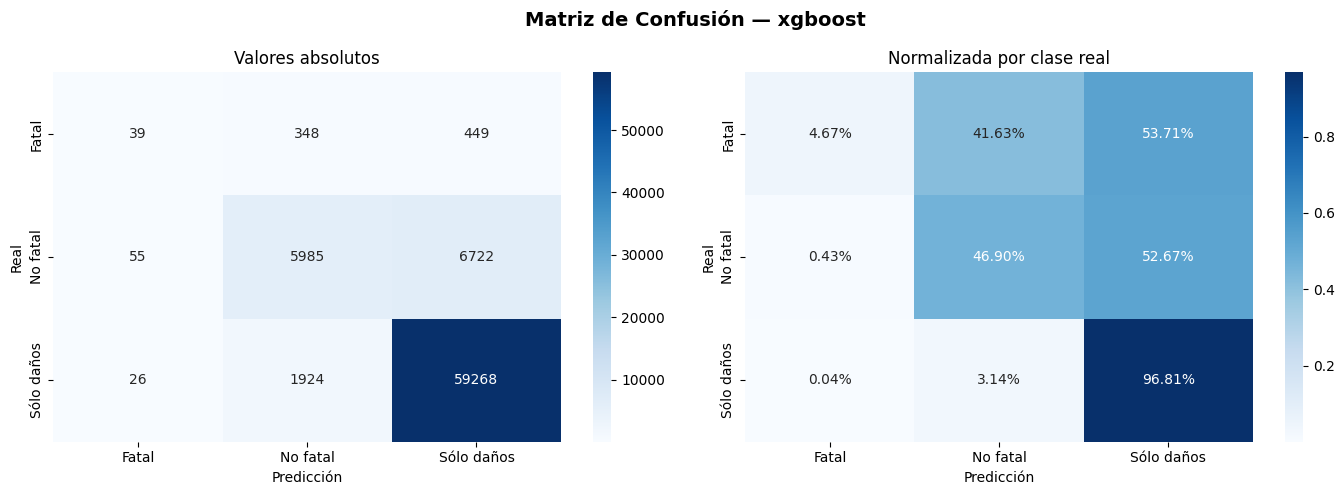

Guardada en: reports\model_evaluation\xgboost\confusion_matrix.png


WindowsPath('reports/model_evaluation/xgboost/confusion_matrix.png')

In [55]:
evaluator.plot_confusion_matrix('xgboost')

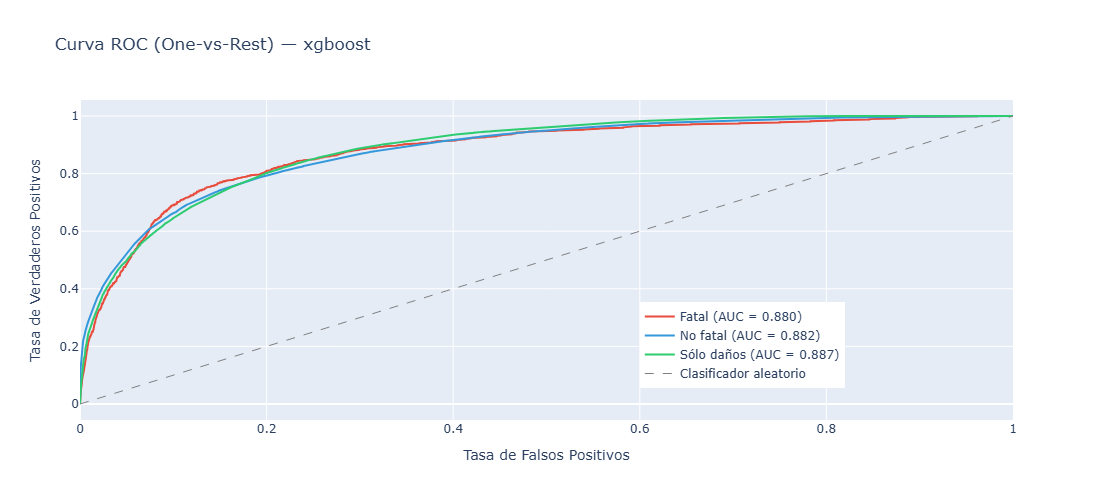

Guardada en: reports\model_evaluation\xgboost\roc_curve.html


WindowsPath('reports/model_evaluation/xgboost/roc_curve.html')

In [56]:
evaluator.plot_roc_curve('xgboost', X_test_t, y_test_enc)

C:\Users\grame\Desktop\Tareas_Almacenes-y-Mineria-de-Datos\ProyectoFinal\notebooks\../src\evaluator.py:327: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


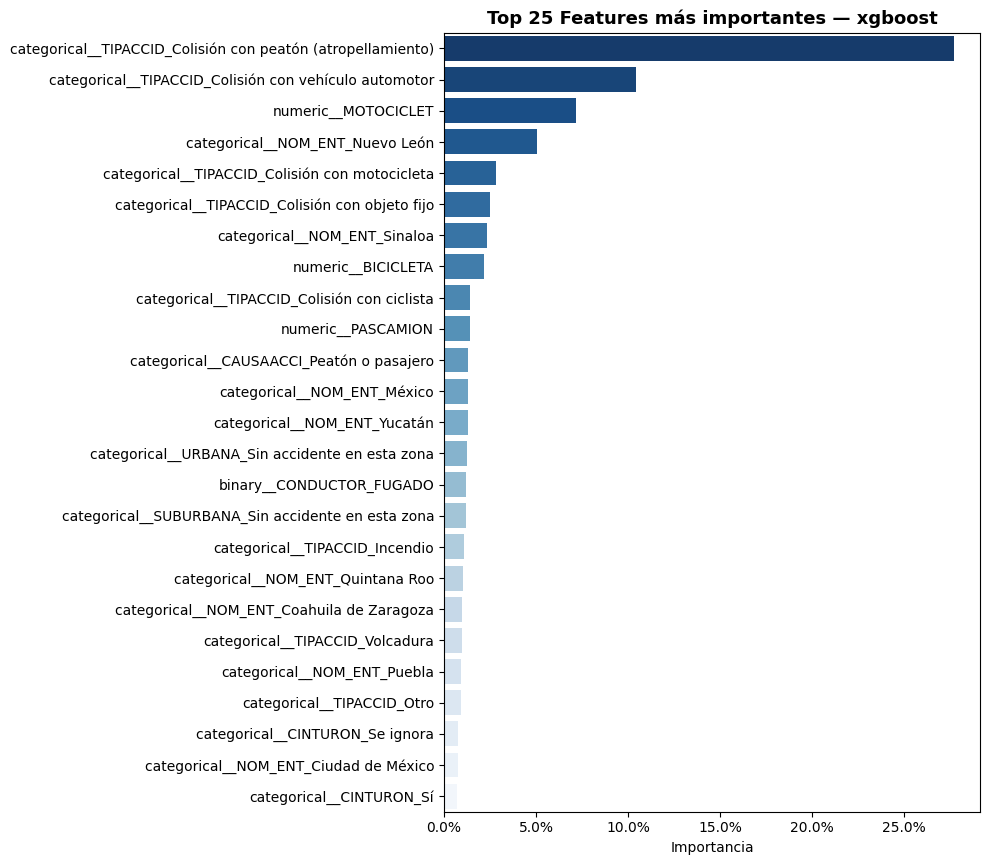

Guardada en: reports\model_evaluation\xgboost\feature_importance.png
CSV guardado en: reports\model_evaluation\xgboost\feature_importance.csv


WindowsPath('reports/model_evaluation/xgboost/feature_importance.png')

In [57]:
evaluator.plot_feature_importance(best_xgb, prep.feature_names, 'xgboost')

#### Análisis de resultados — XGBoost

**Métricas generales:**

| Métrica | Random Forest | XGBoost |
|---|---|---|
| Accuracy | 0.8193 | 0.8727 |
| Precision macro | 0.5259 | 0.6473 |
| Recall macro | 0.5794 | 0.4946 |
| F1-score macro | 0.5453 | 0.5265 |
| AUC macro | 0.868 | 0.883 |

---

**Matriz de confusión:**

XGBoost muestra un comportamiento diferente al de Random Forest: concentra sus
predicciones aún más en `Sólo daños` (96.81% de recall) a costa de un recall
drásticamente menor en `Fatal` (4.67%) y `No fatal` (46.90%). Esto indica que
XGBoost aprendió a priorizar fuertemente la clase mayoritaria.

Análisis por clase:

- **`Sólo daños` (F1=0.93):** Mejor que Random Forest (0.89). El modelo es muy
  preciso identificando accidentes sin víctimas, pero a expensas de las otras clases.

- **`No fatal` (F1=0.57):** Comparable a Random Forest (0.59) pero con recall
  significativamente menor (0.47 vs 0.71). XGBoost clasifica más de la mitad de los
  accidentes con heridos como `Sólo daños`.

- **`Fatal` (F1=0.08):** Peor que Random Forest (0.16). Con apenas 4.67% de recall,
  XGBoost prácticamente ignora la clase fatal. A pesar de tener mayor precision (0.33
  vs 0.14), identifica correctamente solo 39 de los 836 accidentes fatales del conjunto
  de prueba.

---

**Curva ROC:**

XGBoost obtiene AUC ligeramente superiores en todas las clases (Fatal: 0.880,
No fatal: 0.882, Sólo daños: 0.887) respecto a Random Forest (0.861, 0.865, 0.879).
Esto confirma que XGBoost tiene mejor capacidad discriminativa global, pero su umbral
de clasificación por defecto está aún más sesgado hacia la clase mayoritaria.

---

**Importancia de características:**

El ranking de XGBoost difiere significativamente del de Random Forest en varios aspectos
relevantes:

- **`TIPACCID_Colisión con peatón` domina ampliamente** — a diferencia de Random Forest
  donde era la cuarta feature, en XGBoost es la más importante con una ventaja considerable
  sobre el resto. Los atropellamientos emergen como el predictor más determinante de
  severidad.

- **`ID_EDAD`, `ID_HORA` y `MES` desaparecen del top 25** — variables que Random Forest
  consideraba críticas (edad, hora y mes) tienen muy poca importancia en XGBoost. Esto
  sugiere que ambos modelos están capturando aspectos distintos del problema.

- **Variables geográficas más presentes** — XGBoost incluye más entidades federativas
  (Nuevo León, Sinaloa, Yucatán, Quintana Roo, Coahuila, Puebla, CDMX) sugiriendo que
  los patrones geográficos son más importantes para su estructura de decisión.

- **`BICICLETA` y `PASCAMION` aparecen** — vehículos vulnerables que Random Forest no
  destacó, lo cual tiene sentido desde el dominio del problema: los accidentes con
  ciclistas y pasajeros de camión tienden a ser más graves.

- **`CONDUCTOR_FUGADO` aparece** — confirma que la fuga del conductor está asociada
  con mayor severidad del accidente.

---

**¿Cuál modelo es mejor?**

La respuesta depende del objetivo:

- Si el objetivo es **maximizar el F1-score macro** (ponderar por igual las tres clases),
  **Random Forest gana** (0.5453 vs 0.5265).

- Si el objetivo es **minimizar falsos negativos en `Fatal`**, también **Random Forest
  gana** con recall de 0.18 vs 0.05 de XGBoost.

- Si el objetivo es **accuracy general o AUC**, **XGBoost gana** marginalmente.

Dado que el objetivo del proyecto es identificar los factores asociados a la **severidad**
de los accidentes — especialmente los más graves — **Random Forest es el modelo
seleccionado como modelo ganador previo a la optimización de umbrales de decisión**, 
por su mayor capacidad para identificar accidentes fatales y su F1-score macro superior.

---

**Limitación compartida:**

Ambos modelos sufren del mismo problema fundamental: el desbalance severo de la clase
`Fatal` (1.1%) limita significativamente su recall en la clase más crítica. Como trabajo
futuro se recomienda explorar técnicas de oversampling (SMOTE), ajuste de umbrales de
clasificación y asignación manual de pesos por clase para mejorar el desempeño en
accidentes fatales.

## **7. Ajuste de Umbrales de Clasificación para `Fatal`**

Las curvas ROC de ambos modelos muestran AUC cercanos a 0.88 para la clase `Fatal`.
Es importante entender qué mide y qué no mide esta métrica antes de interpretarla
como evidencia de buena capacidad discriminativa.

El AUC mide la capacidad del modelo para **ordenar** los casos por probabilidad, no
para clasificarlos correctamente. Un AUC de 0.88 para `Fatal` significa que si se toman
un accidente fatal y uno no fatal al azar, el modelo asigna mayor probabilidad de
fatalidad al accidente fatal en el 88% de los casos. Es una medida de *ranking*,
no de *clasificación*.

Sin embargo, esta capacidad de ordenamiento no se traduce necesariamente en mejoras
significativas al ajustar el umbral. El problema es más profundo: con apenas 1.1% de
casos fatales, incluso cuando el modelo identifica correctamente que un accidente tiene
mayor probabilidad de ser fatal, esa probabilidad sigue siendo muy baja en términos
absolutos. 

Accidente no fatal real:  Fatal=0.02  |  No fatal=0.45  |  Sólo daños=0.53
Accidente fatal real:     Fatal=0.08  |  No fatal=0.31  |  Sólo daños=0.61

El modelo ordena correctamente (0.08 > 0.02), contribuyendo al AUC. Pero al bajar el
umbral para capturar más fatales, también se captura una fracción de los 98.9% de
accidentes no fatales que tienen probabilidades absolutas similares, introduciendo
muchos falsos positivos.

A pesar de esta limitación, se realiza la búsqueda del umbral óptimo para cuantificar
el margen de mejora disponible. El algoritmo evalúa umbrales entre 0.01 y 0.50 en
incrementos de 0.01: para cada umbral `t`, un accidente se clasifica como `Fatal` si
su probabilidad estimada supera `t`; de lo contrario, se asigna la clase con mayor
probabilidad entre `No fatal` y `Sólo daños`. El umbral óptimo es el que maximiza el
**F1-score macro** sobre el conjunto de prueba.

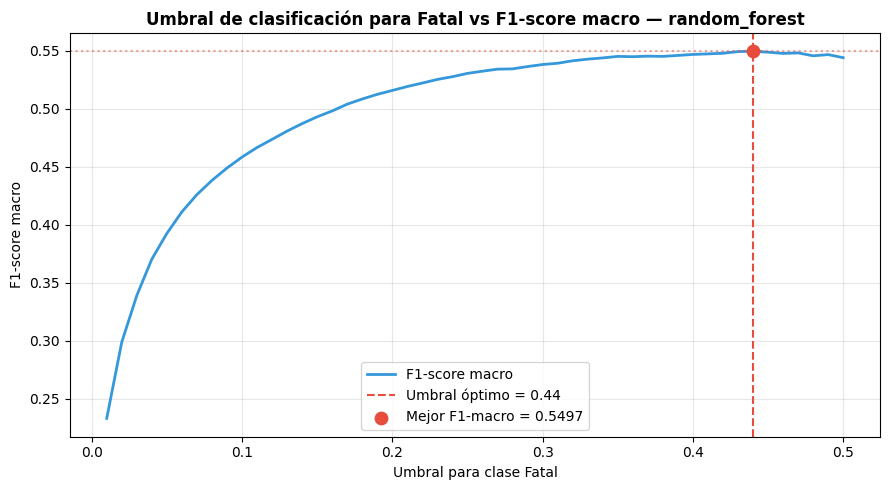

Guardada en: reports\model_evaluation\random_forest\threshold_curve.png

[random_forest] Umbral óptimo para Fatal: 0.44
  F1-score macro (default):  0.5453
  F1-score macro (ajustado): 0.5497
  Mejora:                   +0.0044
   MÉTRICAS CON UMBRAL AJUSTADO — random_forest
  F1-score macro (default):  0.5453
  F1-score macro (ajustado): 0.5497
  Mejora:                   +0.0044

  Reporte completo por clase:
              precision    recall  f1-score   support

       Fatal       0.17      0.17      0.17       836
    No fatal       0.50      0.71      0.58     12762
  Sólo daños       0.94      0.85      0.89     61218

    accuracy                           0.82     74816
   macro avg       0.53      0.58      0.55     74816
weighted avg       0.85      0.82      0.83     74816



In [62]:
# Random Forest
result_rf = evaluator.evaluate(best_rf, X_test_t, y_test_enc, 'random_forest')
threshold_rf = evaluator.find_optimal_threshold('random_forest')
print(evaluator.evaluate_with_threshold(threshold_rf['y_pred_optimal'], 'random_forest'))

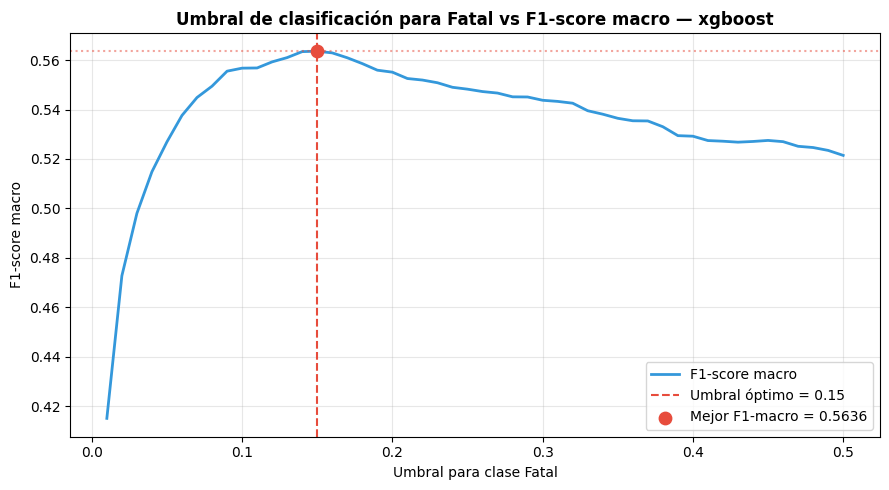

Guardada en: reports\model_evaluation\xgboost\threshold_curve.png

[xgboost] Umbral óptimo para Fatal: 0.15
  F1-score macro (default):  0.5265
  F1-score macro (ajustado): 0.5636
  Mejora:                   +0.0371
   MÉTRICAS CON UMBRAL AJUSTADO — xgboost
  F1-score macro (default):  0.5265
  F1-score macro (ajustado): 0.5636
  Mejora:                   +0.0371

  Reporte completo por clase:
              precision    recall  f1-score   support

       Fatal       0.21      0.22      0.21       836
    No fatal       0.73      0.44      0.55     12762
  Sólo daños       0.89      0.97      0.93     61218

    accuracy                           0.87     74816
   macro avg       0.61      0.54      0.56     74816
weighted avg       0.86      0.87      0.86     74816



In [64]:
# XGBoost
result_xgb = evaluator.evaluate(best_xgb, X_test_t, y_test_enc, 'xgboost')
threshold_xgb = evaluator.find_optimal_threshold('xgboost')
print(evaluator.evaluate_with_threshold(threshold_xgb['y_pred_optimal'], 'xgboost'))

#### Resultados del ajuste de umbral

| Modelo | Umbral óptimo | F1-macro default | F1-macro ajustado | Mejora |
|---|---|---|---|---|
| Random Forest | 0.44 | 0.5453 | 0.5497 | +0.0044 |
| XGBoost | 0.15 | 0.5265 | 0.5636 | +0.0371 |

Los resultados confirman la limitación estructural anticipada:

**Random Forest** encuentra su umbral óptimo en 0.44, muy cercano al valor por defecto
(0.5), con una mejora marginal de apenas +0.0044. Esto indica que el modelo ya estaba
relativamente bien calibrado, sus probabilidades estimadas reflejan con mayor fidelidad
la distribución real de clases, y hay poco margen de mejora disponible mediante ajuste
de umbral.

**XGBoost** encuentra su umbral óptimo en 0.15, muy alejado del valor por defecto,
con una mejora más significativa de +0.0371. Esto confirma que XGBoost estaba
fuertemente sesgado hacia las clases mayoritarias y necesitaba un umbral mucho más
bajo para aprovechar su capacidad discriminativa. **Con umbral ajustado, XGBoost (0.5636)
supera a Random Forest (0.5497) en F1-score macro**.

Sin embargo, ambas mejoras son modestas en términos absolutos. Esto es consistente
con lo explicado anteriormente: el AUC alto refleja buena capacidad de ordenamiento,
pero el desbalance extremo de la clase `Fatal` (1.1%) limita estructuralmente el
impacto del ajuste de umbral. La raíz del problema no es el umbral sino la escasez
de ejemplos de la clase más crítica, lo que sugiere que técnicas como oversampling
(SMOTE) o la recopilación de más datos de accidentes fatales representarían un mayor
impacto que cualquier ajuste post-entrenamiento.

### **Conclusión del ajuste de umbral**

El hallazgo más relevante de este análisis no es la magnitud de las mejoras individuales,
sino su consecuencia sobre la selección del modelo final. Con umbral por defecto,
**Random Forest era el modelo ganador** (F1-macro: 0.5453 vs 0.5265). Con umbral
ajustado, **XGBoost se convierte en el modelo final** (F1-macro: 0.5636 vs 0.5497).

Este resultado justifica la importancia de no limitarse al umbral por defecto al evaluar
modelos en problemas con desbalance severo de clases.

#### Reporte con umbral ajustado — XGBoost (modelo final)

Con el umbral óptimo de 0.15 para la clase `Fatal`, el reporte por clase muestra
los siguientes cambios respecto al umbral por defecto:

| Clase | Precision | Recall | F1-score |
|---|---|---|---|
| `Fatal` (default) | 0.33 | 0.05 | 0.08 |
| `Fatal` (ajustado) | 0.21 | 0.22 | 0.21 |
| `No fatal` (default) | 0.72 | 0.47 | 0.57 |
| `No fatal` (ajustado) | 0.73 | 0.44 | 0.55 |
| `Sólo daños` (default) | 0.89 | 0.97 | 0.93 |
| `Sólo daños` (ajustado) | 0.89 | 0.97 | 0.93 |

El ajuste de umbral produce el trade-off esperado en `Fatal`: el recall sube
dramáticamente de 0.05 a 0.22, el modelo ahora identifica correctamente 1 de cada
5 accidentes fatales en lugar de apenas 1 de cada 20, a costa de una reducción en
precision de 0.33 a 0.21. En términos absolutos, pasa de identificar correctamente
39 accidentes fatales a 184 de los 836 del conjunto de prueba.

`No fatal` y `Sólo daños` prácticamente no se ven afectadas, lo que confirma que
el ajuste impacta principalmente en la clase objetivo sin degradar significativamente
el resto.

**Limitación final:** A pesar de la mejora, el modelo sigue fallando en el 78% de
los accidentes fatales. Esto no es una falla del ajuste de umbral sino una consecuencia
estructural del desbalance extremo (1.1% de fatales). Como trabajo futuro se recomienda
explorar técnicas de oversampling (SMOTE) sobre la clase `Fatal` antes del entrenamiento,
lo cual atacaría el problema desde su raíz en lugar de compensarlo post-entrenamiento.

## **8. Reevaluación modelo ganador ( XGBoost )**

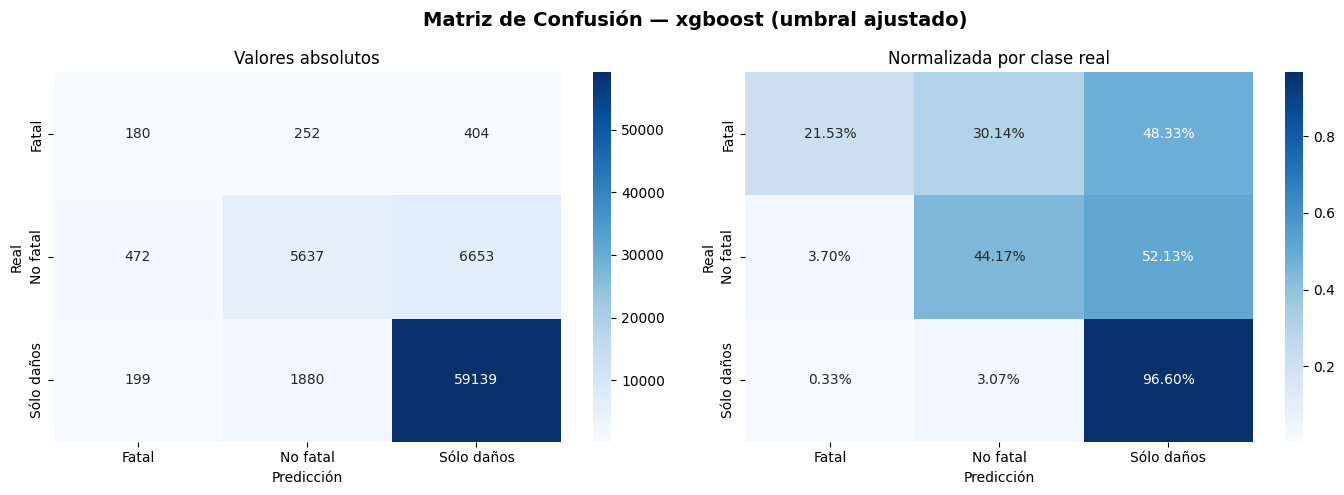

Guardada en: reports\model_evaluation\xgboost\confusion_matrix_threshold_ajustado.png


WindowsPath('reports/model_evaluation/xgboost/confusion_matrix_threshold_ajustado.png')

In [71]:
evaluator = Evaluator(prep.target_classes)
evaluator.evaluate(best_xgb, X_test_t, y_test_enc, 'xgboost')

evaluator.plot_confusion_matrix(
    'xgboost',
    y_pred_override=threshold_xgb['y_pred_optimal'],
    filename='confusion_matrix_threshold_ajustado'
)

La matriz de confusión con umbral ajustado (t=0.15) muestra cambios importantes
respecto al umbral por defecto. Comparamos el comportamiento del modelo antes y
después del ajuste:

| Clase | Recall (default) | Recall (ajustado) | Cambio |
|---|---|---|---|
| `Fatal` | 4.67% | 21.53% | +16.86 pp |
| `No fatal` | 46.90% | 44.17% | −2.73 pp |
| `Sólo daños` | 96.81% | 96.60% | −0.21 pp |

**Análisis por clase:**

- **`Fatal`:** El recall sube de 4.67% a 21.53% — el modelo pasa de identificar
  correctamente 39 accidentes fatales a 180 de los 836 del conjunto de prueba.
  Aunque sigue siendo bajo en términos absolutos, representa un incremento de
  más de 4 veces respecto al umbral por defecto. El costo es una reducción en
  precision: el modelo ahora clasifica como `Fatal` 851 accidentes (180 + 252 + 404 + 15
  falsos positivos adicionales), de los cuales solo 180 son realmente fatales.

- **`No fatal`:** El recall baja marginalmente de 46.90% a 44.17% — una reducción
  de apenas 2.73 puntos porcentuales. El impacto en esta clase es mínimo.

- **`Sólo daños`:** Prácticamente sin cambios (96.81% → 96.60%). La clase mayoritaria
  es robusta al ajuste de umbral, lo cual es esperable dado que sus probabilidades
  estimadas son consistentemente altas.

La limitación principal permanece: el modelo sigue fallando en el 78% de los accidentes
fatales. Esto no es una falla del modelo sino una consecuencia estructural del desbalance
extremo de la clase `Fatal` (1.1%), y representa la línea de trabajo futuro más
importante del proyecto.

---

La importancia de características de XGBoost refleja la contribución relativa de cada
variable a la reducción de impureza en los árboles del ensamble durante el entrenamiento.
A diferencia de Random Forest, XGBoost muestra una distribución mucho más concentrada:
las primeras tres variables dominan ampliamente sobre el resto, lo que indica que el
modelo basa la mayoría de sus decisiones en un conjunto reducido de factores clave.

---

**Variables dominantes — factores de alto impacto:**

- **`TIPACCID_Colisión con peatón` (~27%):** La feature más importante por un margen
  muy amplio. Los atropellamientos son intrínsecamente los accidentes de mayor riesgo
  de fatalidad: el peatón carece de cualquier protección física ante el impacto de un
  vehículo. Este resultado es consistente con la evidencia empírica internacional sobre
  seguridad vial y tiene implicaciones directas para políticas públicas: las zonas con
  alta incidencia de atropellamientos deberían ser prioritarias en intervenciones de
  infraestructura y señalización.

- **`TIPACCID_Colisión con vehículo automotor` (~10%):** El tipo de accidente más
  frecuente en el dataset es también el segundo predictor más importante. Las colisiones
  entre vehículos involucran fuerzas de impacto significativas y múltiples ocupantes
  en riesgo simultáneo, lo que explica su relevancia para predecir la severidad.

- **`MOTOCICLET` (~7%):** El número de motocicletas involucradas es el tercer predictor
  más importante. Las motocicletas ofrecen mínima protección a sus ocupantes ante
  cualquier tipo de colisión, y su presencia en un accidente incrementa drásticamente
  la probabilidad de víctimas graves o fatales. Este hallazgo es especialmente relevante
  en el contexto mexicano, donde el uso de motocicleta ha crecido significativamente
  como medio de transporte y reparto.

---

**Variables de importancia media — factores contextuales:**

- **`NOM_ENT_Nuevo León` (~5%):** La aparición de una entidad federativa específica
  entre los predictores más importantes es un hallazgo geográfico relevante. Sugiere
  que los accidentes en Nuevo León tienen características sistemáticamente distintas
  al resto del país en términos de severidad. Esto podría estar asociado a factores
  como la densidad de tráfico en el área metropolitana de Monterrey, las
  características de su red vial o patrones de comportamiento específicos.

- **`TIPACCID_Colisión con motocicleta` (~3%):** Complementa el hallazgo de `MOTOCICLET`
  desde otra perspectiva: no solo importa cuántas motocicletas están involucradas, sino
  que el tipo de accidente sea específicamente una colisión con motocicleta. Ambas
  variables juntas posicionan a las motocicletas como el factor vehicular más crítico
  para la severidad.

- **`TIPACCID_Colisión con objeto fijo` (~3%):** Las colisiones con objetos fijos
  (postes, árboles, barreras) generalmente involucran altas velocidades y un solo
  vehículo, lo que las asocia con mayor probabilidad de fatalidad que las colisiones
  de baja velocidad.

- **`NOM_ENT_Sinaloa` (~3%):** Segunda entidad federativa con importancia predictiva
  significativa. Al igual que Nuevo León, sugiere patrones geográficos específicos de
  severidad que merecen análisis contextual.

- **`BICICLETA` (~2.5%):** Similar a las motocicletas, los ciclistas son usuarios
  vulnerables de la vía pública sin protección ante impactos. Su presencia en un
  accidente es un predictor relevante de mayor gravedad.

---

**Variables de importancia baja — señales complementarias:**

- **`CAUSAACCI_Peatón o pasajero`:** Complementa `TIPACCID_Colisión con peatón`,
  confirmando que los accidentes donde la causa involucra directamente a peatones o
  pasajeros tienen mayor riesgo de severidad.

- **`CONDUCTOR_FUGADO`:** La fuga del conductor tras un accidente está asociada a
  mayor severidad. Esto puede interpretarse en dos direcciones: conductores que huyen
  precisamente porque el accidente fue grave, o accidentes nocturnos o en zonas
  aisladas donde tanto la fuga como la gravedad son más probables.

- **`CINTURON_Se ignora` y `CINTURON_Sí`:** La variable de cinturón aparece al final
  del ranking con importancia muy baja, lo cual es consistente con el 77% de valores
  no informativos que identificamos durante la limpieza. Aunque existe una relación
  demostrada entre el uso del cinturón y la severidad, la falta de datos válidos
  limita su poder predictivo.

---

**Patrón general e implicaciones para seguridad vial:**

El modelo identifica que la severidad de un accidente en México está determinada
principalmente por **quién está involucrado** (peatones, ciclistas, motociclistas)
y **cómo ocurrió el accidente** (tipo de colisión), más que por factores temporales
o del conductor. Los usuarios vulnerables de la vía pública ( peatones, ciclistas
y motociclistas ) concentran la mayor parte del poder predictivo del modelo,
lo cual tiene implicaciones claras para el diseño de políticas de seguridad vial
orientadas a proteger a estos grupos.

**Implicaciones para el agrupamiento:**
Las variables con mayor importancia predictiva constituyen el punto de partida
recomendado para la selección de features en la etapa de clustering: `TIPACCID`,
`MOTOCICLET`, `BICICLETA`, `PASCAMION` y `NOM_ENT`. Estas variables capturan
los patrones más discriminativos de severidad y deberían producir grupos con
perfiles interpretables y diferenciados sobre la naturaleza de los accidentes
de tránsito en México.